# 1. IMPORTING LIBRARIES

In [158]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import datetime as dt
import os

# 2. LOADING THE FILES

In [134]:
print(os.getcwd())

/home/kenneth28/my_projects/PROJECTS/geo_analysis


In [186]:
folder = os.getcwd()
filename = "EARTHQUAKE ANALYSIS YEAR 1970-2014/earthquakes1970-2014.csv"

path = os.path.join(folder,filename)
df = pd.read_csv(path)

# 'Longitude' and 'Latitude' columns
geometry = [Point(xy) for xy in zip(df["Longitude"], df["Latitude"])]

# Convert to GeoDataFrame
earthquakes = gpd.GeoDataFrame(df, geometry=geometry, crs="EPSG:4326")

print(earthquakes.head())
print(earthquakes.crs)

                 DateTime  Latitude  Longitude  Depth  Magnitude MagType  \
0  1970/01/04 17:00:40.20    24.139    102.503   31.0        7.5      Ms   
1  1970/01/06 05:35:51.80    -9.628    151.458    8.0        6.2      Ms   
2  1970/01/08 17:12:39.10   -34.741    178.568  179.0        6.1      Mb   
3  1970/01/10 12:07:08.60     6.825    126.737   73.0        6.1      Mb   
4  1970/01/16 08:05:39.00    60.280   -152.660   85.0        6.0      ML   

   NbStations  Gap  Distance  RMS Source       EventID  \
0        90.0  NaN       NaN  0.0    NEI  1.970010e+09   
1        85.0  NaN       NaN  0.0    NEI  1.970011e+09   
2        59.0  NaN       NaN  0.0    NEI  1.970011e+09   
3        91.0  NaN       NaN  0.0    NEI  1.970011e+09   
4         0.0  NaN       NaN  NaN     AK           NaN   

                  geometry  
0   POINT (102.503 24.139)  
1   POINT (151.458 -9.628)  
2  POINT (178.568 -34.741)  
3    POINT (126.737 6.825)  
4    POINT (-152.66 60.28)  
EPSG:4326


# 3. DATA EXPLORATION

# 4. DATA PROFILING

In [138]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Latitude,5304.0,2.590360e+00,2.987294e+01,-66.448,-1.773525e+01,-3.493000e+00,2.817175e+01,8.494800e+01
Longitude,5304.0,4.464122e+01,1.247920e+02,-179.989,-7.365350e+01,1.183555e+02,1.469945e+02,1.799980e+02
Depth,5304.0,7.426804e+01,1.290923e+02,0.000,1.450000e+01,3.300000e+01,5.230000e+01,6.880000e+02
Magnitude,5304.0,6.369114e+00,4.190542e-01,6.000,6.100000e+00,6.200000e+00,6.500000e+00,9.100000e+00
NbStations,5250.0,3.017739e+02,1.709588e+02,0.000,1.610000e+02,2.895000e+02,4.240000e+02,9.340000e+02
Gap,172.0,4.909884e+01,5.288813e+01,0.000,1.800000e+01,2.800000e+01,5.500000e+01,2.620000e+02
Distance,170.0,6.605882e+00,1.003267e+01,0.000,2.000000e+00,4.000000e+00,6.000000e+00,7.700000e+01
RMS,5264.0,8.169263e-01,5.596820e-01,0.000,7.800000e-01,9.700000e-01,1.110000e+00,2.430000e+01
EventID,5242.0,1.980309e+09,1.697093e+08,9.000,1.983103e+09,1.997040e+09,2.006052e+09,2.014011e+09


In [139]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5304 entries, 0 to 5303
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DateTime    5304 non-null   object 
 1   Latitude    5304 non-null   float64
 2   Longitude   5304 non-null   float64
 3   Depth       5304 non-null   float64
 4   Magnitude   5304 non-null   float64
 5   MagType     5304 non-null   object 
 6   NbStations  5250 non-null   float64
 7   Gap         172 non-null    float64
 8   Distance    170 non-null    float64
 9   RMS         5264 non-null   float64
 10  Source      5304 non-null   object 
 11  EventID     5242 non-null   float64
dtypes: float64(9), object(3)
memory usage: 497.4+ KB


In [83]:
df.isnull().sum()

DateTime         0
Latitude         0
Longitude        0
Depth            0
Magnitude        0
MagType          0
NbStations      54
Gap           5132
Distance      5134
RMS             40
Source           0
EventID         62
dtype: int64

## 4.1 COLUMNS PROFILE

DateTime: The date and time when earthquake occured.

Latitude (degree): Geographic coordinate that specifies the north-south position of a point on the Earth's surface (Horizontally Run around the Earth) / Parallel to Equator.

Longitude (degree): Geographic coordinate that specifies the east-west position of a point on the surface of the Earth, or another celestial body. It is an angular measurement, usually expressed in degrees and denoted by the Greek letter lambda (λ) (Vertically Run around the Earth) / Parallel to Prime Meridian.

Depth (km) : The depth of an earthquake is a critical parameter that influences the earthquake's impact on the Earth's surface. It is measured in kilometers and is crucial for understanding the earthquake's potential consequences.

a. Shallow earthquakes (0-70 km) are characterized by a high amplitude of surface waves and a simple P and S wave pattern, indicating a shallow focus. 
b. Intermediate earthquakes (70-300 km) have a moderate amplitude of surface waves and a complex P and S wave pattern, suggesting a deeper focus. 
c. Deep earthquakes (300-700 km) are associated with great slabs of lithosphere sinking into the mantle, and their depth is determined by the travel-time curves of P and S waves. 

Understanding the depth of an earthquake is essential for assessing seismic hazards and developing effective earthquake risk mitigation strategies. The depth data is often reported alongside the earthquake's magnitude, which is the most widely reported metric. However, it is important to consider both depth and magnitude together to fully understand the earthquake's potential impact.

Magnitude (Logarithmic): Earthquake magnitude measures the size or energy release of an earthquake, typically on a logarithmic scale where each whole number increase represents roughly 31.6 times more energy released.

Magtype (Type): Magnitude Scale Type

- Mw (Moment Magnitude, 2416 records) → the modern standard; based on seismic moment (fault area × slip × rigidity). Best for large quakes.
- Ms (Surface-wave magnitude, 1256) → based on amplitude of surface waves. Good for shallow, distant quakes.
- Mb (Body-wave magnitude, 895) → based on P‑wave amplitude. Often used for smaller or deeper quakes.
- Me (Energy magnitude, 404) → derived from total radiated seismic energy.
- ML (Local magnitude, 76) → the original Richter scale, used for small, local events.
- Mc (Coda magnitude, 4) → based on duration of seismic signal (coda waves).
- Md (Duration magnitude, 1) → similar to Mc, based on signal length.
- Unk (Unknown, 252) → magnitude type not specified.

NbStations (Continuos): Refers to the Number of Stations that contributed seismic readings used to calculate the magnitude. It is the weighing confidence in magnitude.

- Low NBStations → magnitude may be less accurate (few sensors, poor coverage).
- High NBStations → more robust estimate, less uncertainty.

Gap: Largest azimuthal gap in the distribution of seismic stations that recorded the event.

Distance: Field usually refers to the distance between the earthquake epicenter and the nearest seismic station (sometimes called minimum station distance).

RMS (Continuos): Refers to the Root Mean Square of the travel‑time residuals from seismic stations.

Source (Type): Indicates the origin of the event record — essentially, which seismic network, agency, or database contributed the information.

EventID: Unique Identifier of Earthquake event

# 5. DATA CLEANING AND FEATURE EXTRACTION FOR FUTURE ANALYSIS

## 5.1 GAP and Distance Distribution

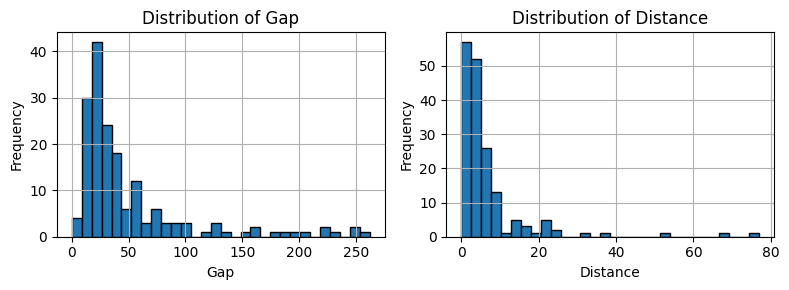

In [157]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Histogram of Gap
df["Gap"].hist(bins=30, edgecolor="black", ax=axes[0])
axes[0].set_xlabel("Gap")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Gap")

# Histogram of Distance
df["Distance"].hist(bins=30, edgecolor="black", ax=axes[1])
axes[1].set_xlabel("Distance")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Distance")

plt.tight_layout()
plt.show()

In [23]:
df["MagType"].value_counts()

MagType
Mw     2416
Ms     1256
Mb      895
Me      404
Unk     252
ML       76
Mc        4
Md        1
Name: count, dtype: int64

In [24]:
df["Source"].value_counts()

Source
NEI    5110
AK       57
us       53
NC       17
CI       11
PGC       8
UW        6
GUC       6
HV        6
WEL       5
UNM       4
ROM       3
MDD       2
ISK       2
ATH       2
AEI       2
DOE       1
UU        1
NN        1
WY        1
REN       1
CAS       1
SJA       1
JMA       1
UCR       1
us_       1
Name: count, dtype: int64

- Mw (Moment Magnitude, 2416 records) → the modern standard; based on seismic moment (fault area × slip × rigidity). Best for large quakes.
- Ms (Surface-wave magnitude, 1256) → based on amplitude of surface waves. Good for shallow, distant quakes.
- Mb (Body-wave magnitude, 895) → based on P‑wave amplitude. Often used for smaller or deeper quakes.
- Me (Energy magnitude, 404) → derived from total radiated seismic energy.
- ML (Local magnitude, 76) → the original Richter scale, used for small, local events.
- Mc (Coda magnitude, 4) → based on duration of seismic signal (coda waves).
- Md (Duration magnitude, 1) → similar to Mc, based on signal length.
- Unk (Unknown, 252) → magnitude type not specified.

In [28]:
df[df["NbStations"].isnull()]

,DateTime,Latitude,Longitude,Depth,Magnitude,MagType,NbStations,Gap,Distance,RMS,Source,EventID
5247,2013/08/01 20:01:43.16,-15.2443,-173.5006,31.65,6.0,Mw,NaN,38.0,2.0,0.67,us,2.013080e+09
5248,2013/08/12 00:53:43.98,-7.1354,129.8088,95.00,6.0,Mw,NaN,13.0,2.0,0.68,us,2.013081e+09
5250,2013/08/12 09:49:32.36,-5.3962,-81.9268,10.00,6.2,Mw,NaN,26.0,4.0,1.27,us,2.013081e+09
5251,2013/08/13 15:43:15.20,5.7732,-78.1999,12.00,6.7,Mw,NaN,22.0,4.0,0.84,us,2.013081e+09
5252,2013/08/16 02:31:05.75,-41.7340,174.1520,8.20,6.5,Mw,NaN,NaN,NaN,1.19,us_,2.013082e+09
5253,2013/08/17 16:32:31.41,-34.8853,54.0927,10.00,6.1,Mw,NaN,22.0,15.0,0.83,us,2.013082e+09
5254,2013/08/21 12:38:29.47,16.8451,-99.5286,21.00,6.2,Mw,NaN,45.0,1.0,1.09,us,2.013082e+09
5257,2013/09/01 11:52:29.93,-7.4400,128.2209,112.00,6.5,Mw,NaN,11.0,3.0,1.12,us,2.013090e+09
5258,2013/09/03 20:19:06.34,51.2440,-130.3971,2.73,6.1,Mw,NaN,44.0,2.0,0.93,us,2.013090e+09
5259,2013/09/04 00:18:23.37,29.9377,138.8325,402.00,6.5,Mw,NaN,26.0,3.0,1.02,us,2.013090e+09


Null NbStations are in us source & NbStations are also in Mw Magtype

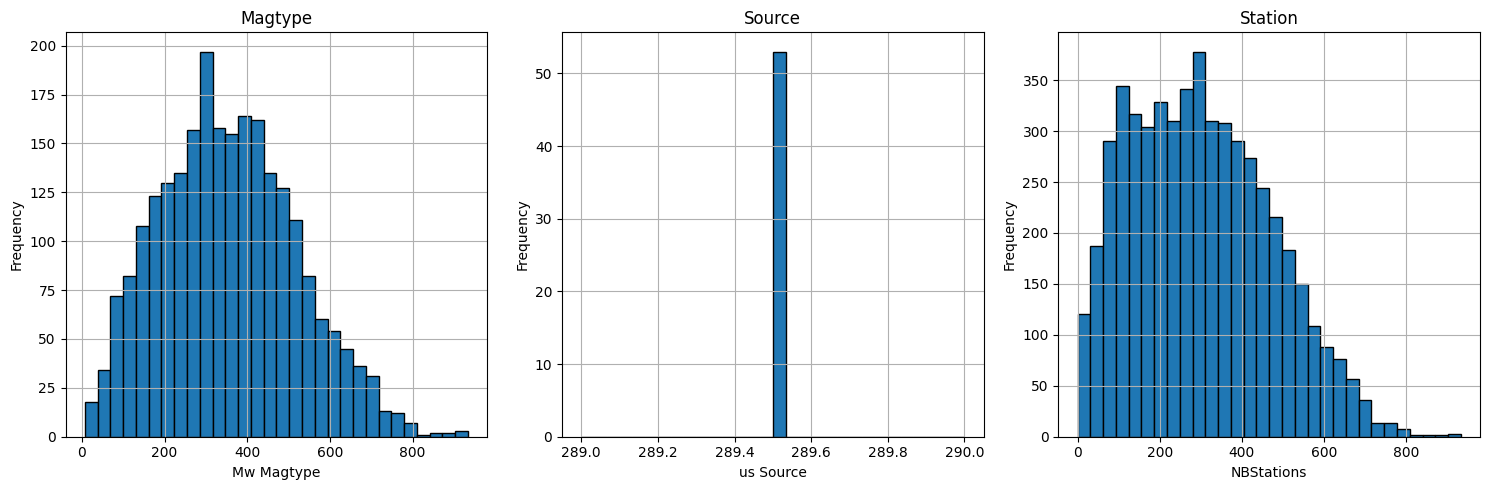

In [124]:
subset_mw = df[df["MagType"] == "Mw"]
subset_us = df[df["Source"] == "us"]
subset_nb = df["NbStations"].fillna(0) 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

subset_mw["NbStations"].hist(bins=30, edgecolor="black",ax=axes[0])
axes[0].set_xlabel("Mw Magtype")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Magtype")

subset_us["NbStations"].hist(bins=30, edgecolor="black",ax=axes[1])
axes[1].set_xlabel("us Source")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Source")

subset_nb.hist(bins=30, edgecolor="black",ax=axes[2])
axes[2].set_xlabel("NBStations")
axes[2].set_ylabel("Frequency")
axes[2].set_title("Station")

plt.tight_layout()
plt.show()

### FILL NULL NBSTATIONS COLUMN

In [165]:
''' We'll just fill median of NbStations since the distribution is not uniform.
    As we can see, Mw Magtype, Source, and NbStations has approximately have median ranging from 290-350
    '''
print(
    f"Mw magtype has {subset_mw["NbStations"].median()} median, "
    f"US source has {subset_us["NbStations"].median()} median, "
    f"NB Stations has {subset_nb.median()} median"
)

med_st = df["NbStations"].median()
print(f"We'll replace null NbStations with NbStations median: {med_st}")
df["NbStations"] = df["NbStations"].fillna(med_st)
# Check if any nulls remain in NBStations
print(df["NbStations"].isnull().sum())

Mw magtype has 345.5 median, US source has 289.5 median, NB Stations has 289.5 median
We'll replace null NbStations with NbStations median: 289.5
0


### RMS COLUMN EXPLORATION

In [91]:
df[df["RMS"].isnull()]

,DateTime,Latitude,Longitude,Depth,Magnitude,MagType,NbStations,Gap,Distance,RMS,Source,EventID
4,1970/01/16 08:05:39.00,60.2800,-152.6600,85.0,6.0,ML,0.0,NaN,NaN,NaN,AK,NaN
13,1970/02/27 07:07:56.50,50.1300,-179.5898,7.0,6.0,ML,0.0,NaN,NaN,NaN,AK,NaN
14,1970/02/28 10:52:31.10,52.5898,-175.0400,161.0,6.1,ML,0.0,NaN,NaN,NaN,AK,NaN
18,1970/03/11 22:38:32.40,57.3900,-153.9700,16.0,6.5,ML,0.0,NaN,NaN,NaN,AK,NaN
20,1970/03/19 23:33:28.70,51.3400,173.7500,8.0,6.5,ML,0.0,NaN,NaN,NaN,AK,NaN
28,1970/04/11 04:05:42.90,59.7200,-142.4900,7.0,6.2,ML,0.0,NaN,NaN,NaN,AK,NaN
31,1970/04/16 05:33:18.20,59.8400,-142.4300,7.0,6.8,ML,0.0,NaN,NaN,NaN,AK,NaN
32,1970/04/19 01:15:47.00,59.6000,-142.7200,20.0,6.0,ML,0.0,NaN,NaN,NaN,AK,NaN
74,1970/08/18 17:52:08.39,60.7000,-145.3800,30.0,6.0,ML,0.0,NaN,NaN,NaN,AK,NaN
98,1970/12/01 21:09:37.00,51.4400,-175.3300,32.0,6.0,ML,0.0,NaN,NaN,NaN,AK,NaN


Null RMS are in AK source & NbStations are also in ML Magtype.

Please also note that RMS is too Sparse.

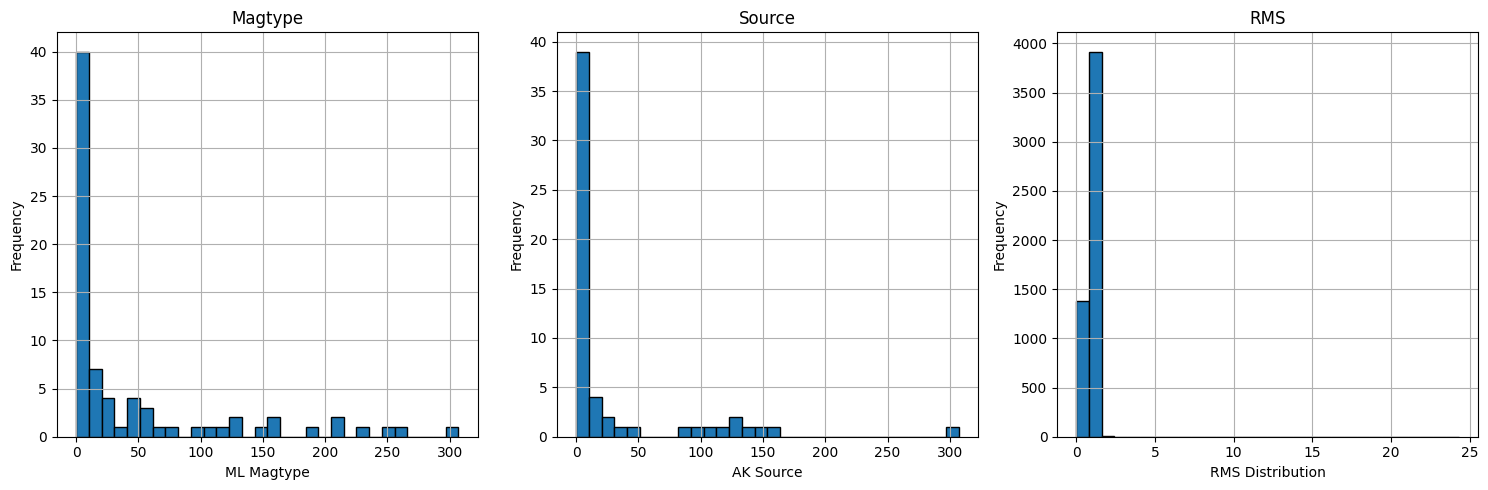

In [128]:
subset_ml = df[df["MagType"] == "ML"]
subset_ak = df[df["Source"] == "AK"]
subset_rms = df["RMS"].fillna(0) 

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

subset_ml["NbStations"].hist(bins=30, edgecolor="black",ax=axes[0])
axes[0].set_xlabel("ML Magtype")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Magtype")

subset_ak["NbStations"].hist(bins=30, edgecolor="black",ax=axes[1])
axes[1].set_xlabel("AK Source")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Source")

subset_rms.hist(bins=30, edgecolor="black",ax=axes[2])
axes[2].set_xlabel("RMS Distribution")
axes[2].set_ylabel("Frequency")
axes[2].set_title("RMS")

plt.tight_layout()
plt.show()

### FILL RMS COLUMN

In [167]:
''' We'll just fill median of NbStations since the distribution is not uniform.
    As we can see, Mw Magtype, Source, and NbStations has approximately have median ranging from 0.90-0.2
    '''

print(
    f"ML magtype has {subset_ml["RMS"].median()} median, "
    f"AK source has {subset_ak["RMS"].median()} median, "
    f"RMS Stations has {subset_rms.median()} median"
)

med_rms = df["RMS"].median()
print(f"We'll replace null RMS columns with RMS median: {med_rms}")
df["RMS"] = df["RMS"].fillna(med_rms)
# Check if any nulls remain in NBStations
print(df["RMS"].isnull().sum())

ML magtype has 0.97 median, AK source has 0.97 median, RMS Stations has 0.97 median
We'll replace null RMS columns with RMS median: 0.97
0


We we'll **exclude a. GAP, b. Distance, and c. Event ID from the analysis.** Since GAP and Distance have over 5,100 missing values.

Here, we'll assume scenarios.

Both GAP and Distance has not been recorded by certain stations.

- Applying (mean/median) imputation would introduce bias and add noise to the dataset.
- Applying binary decision flag (Gap Missing or Distance Missing) is not ideal since it is not relevant to earthquake prediction.

GAP and Distance can still be represented by Source and RMS along with Longitude and Latitude.

In [198]:
df["RMS"] = df["RMS"].fillna(0)
df["NbStations"] = df["NbStations"].fillna(med_st)

eqdf = df[["DateTime", "Latitude", "Longitude", "Depth", "Magnitude", "MagType", "NbStations", "RMS", "Source"]]
eqdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5304 entries, 0 to 5303
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DateTime    5304 non-null   datetime64[ns]
 1   Latitude    5304 non-null   float64       
 2   Longitude   5304 non-null   float64       
 3   Depth       5304 non-null   float64       
 4   Magnitude   5304 non-null   float64       
 5   MagType     5304 non-null   object        
 6   NbStations  5304 non-null   float64       
 7   RMS         5304 non-null   float64       
 8   Source      5304 non-null   object        
dtypes: datetime64[ns](1), float64(6), object(2)
memory usage: 373.1+ KB


In [202]:
df["DateTime"] = pd.to_datetime(df["DateTime"])

df["Time"] = df["DateTime"].dt.time

df["Day"] = df["DateTime"].dt.day
df["Month"] = df["DateTime"].dt.month
df["Year"] = df["DateTime"].dt.year
df["Hour"] = df["DateTime"].dt.hour

In [190]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5304 entries, 0 to 5303
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   DateTime    5304 non-null   datetime64[ns]
 1   Latitude    5304 non-null   float64       
 2   Longitude   5304 non-null   float64       
 3   Depth       5304 non-null   float64       
 4   Magnitude   5304 non-null   float64       
 5   MagType     5304 non-null   object        
 6   NbStations  5250 non-null   float64       
 7   Gap         172 non-null    float64       
 8   Distance    170 non-null    float64       
 9   RMS         5264 non-null   float64       
 10  Source      5304 non-null   object        
 11  EventID     5242 non-null   float64       
 12  Time        5304 non-null   object        
 13  Day         5304 non-null   int32         
 14  Month       5304 non-null   int32         
 15  Year        5304 non-null   int32         
 16  Hour        5304 non-nul

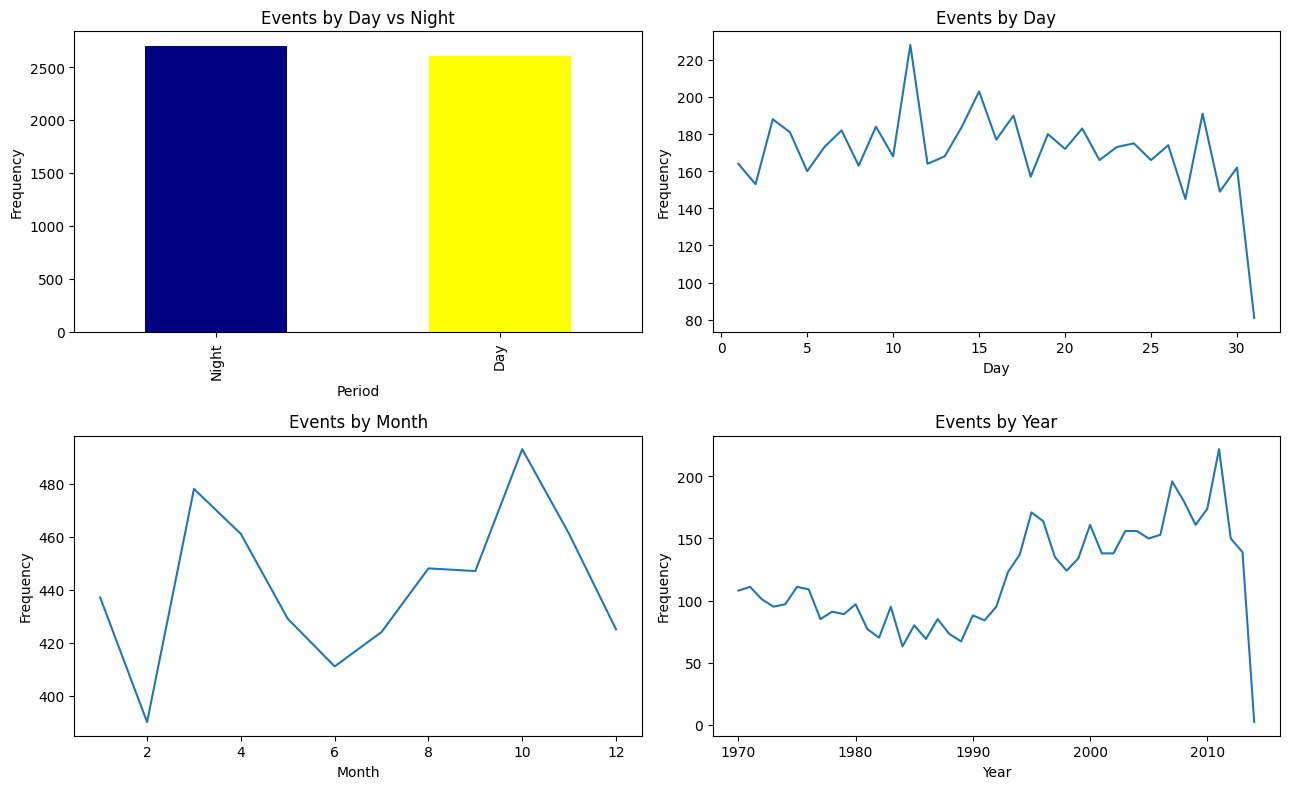

In [191]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Define day vs night
df["DayNight"] = df["Hour"].apply(lambda h: "Day" if 6 <= h < 18 else "Night")

# Bar plot of Day vs Night
df["DayNight"].value_counts().plot(kind="bar", color=["navy","yellow"], ax=axes[0,0])
axes[0,0].set_xlabel("Period")
axes[0,0].set_ylabel("Frequency")
axes[0,0].set_title("Events by Day vs Night")

# Line chart of Day
df["Day"].value_counts().sort_index().plot(kind="line", ax=axes[0,1])
axes[0,1].set_xlabel("Day")
axes[0,1].set_ylabel("Frequency")
axes[0,1].set_title("Events by Day")

# Line chart of Month
df["Month"].value_counts().sort_index().plot(kind="line", ax=axes[1,0])
axes[1,0].set_xlabel("Month")
axes[1,0].set_ylabel("Frequency")
axes[1,0].set_title("Events by Month")

# Line chart of Year
df["Year"].value_counts().sort_index().plot(kind="line", ax=axes[1,1])
axes[1,1].set_xlabel("Year")
axes[1,1].set_ylabel("Frequency")
axes[1,1].set_title("Events by Year")

plt.tight_layout()
plt.show()

## EXCLUDING DATA WHERE YEAR>2014

In [204]:
eqdf_2014 = df[df["Year"] >= 2014]
print(eqdf_2014)

                    DateTime  Latitude  Longitude  Depth  Magnitude MagType  \
5302 2014-01-01 16:03:28.890  -13.8779   167.2434  187.0        6.5      Mw   
5303 2014-01-13 04:01:04.690   19.0014   -66.8478   28.0        6.4      Mw   

      NbStations   Gap  Distance   RMS Source       EventID             Time  \
5302       289.5  14.0       4.0  0.67     us  2.014010e+09  16:03:28.890000   
5303       289.5  21.0       1.0  1.42     us  2.014011e+09  04:01:04.690000   

      Day  Month  Year  Hour DayNight  
5302    1      1  2014    16      Day  
5303   13      1  2014     4    Night  


### 2 Records only in 2014. It means our dataset shoud be 1970-2013 only.

In [205]:
eqdf = df[["DateTime", "Day","Month","Year","Hour","Latitude", "Longitude", "Depth", "Magnitude", "MagType", "NbStations", "RMS", "Source"]]

eqdf = eqdf[eqdf["Year"] < 2014]
print(eqdf.head())

                 DateTime  Day  Month  Year  Hour  Latitude  Longitude  Depth  \
0 1970-01-04 17:00:40.200    4      1  1970    17    24.139    102.503   31.0   
1 1970-01-06 05:35:51.800    6      1  1970     5    -9.628    151.458    8.0   
2 1970-01-08 17:12:39.100    8      1  1970    17   -34.741    178.568  179.0   
3 1970-01-10 12:07:08.600   10      1  1970    12     6.825    126.737   73.0   
4 1970-01-16 08:05:39.000   16      1  1970     8    60.280   -152.660   85.0   

   Magnitude MagType  NbStations  RMS Source  
0        7.5      Ms        90.0  0.0    NEI  
1        6.2      Ms        85.0  0.0    NEI  
2        6.1      Mb        59.0  0.0    NEI  
3        6.1      Mb        91.0  0.0    NEI  
4        6.0      ML         0.0  0.0     AK  


## 4.2 EXPORTING COLUMNS FOR DATA VISUALIZATION

In [206]:
eqdf.to_csv("EARTHQUAKE ANALYSIS YEAR 1970-2014/earthquakes1970-2013.csv_imp.csv", index=False)

# 6. EXTRACT COUNTRY NAME USING GEOPANDAS

In [211]:
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")

gdf_points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df["Longitude"], df["Latitude"]),
    crs="EPSG:4326"
)

result = gpd.sjoin(gdf_points, world, how="left", predicate="within")

df["Country"] = result["ADMIN"].fillna("Ocean")

print(df)

                    DateTime  Latitude  Longitude   Depth  Magnitude MagType  \
0    1970-01-04 17:00:40.200   24.1390   102.5030   31.00        7.5      Ms   
1    1970-01-06 05:35:51.800   -9.6280   151.4580    8.00        6.2      Ms   
2    1970-01-08 17:12:39.100  -34.7410   178.5680  179.00        6.1      Mb   
3    1970-01-10 12:07:08.600    6.8250   126.7370   73.00        6.1      Mb   
4    1970-01-16 08:05:39.000   60.2800  -152.6600   85.00        6.0      ML   
...                      ...       ...        ...     ...        ...     ...   
5299 2013-12-01 06:29:57.800    2.0440    96.8261   20.00        6.0      Mw   
5300 2013-12-08 17:24:54.200   44.4438   149.1667   28.00        6.1      Mw   
5301 2013-12-17 23:38:08.100   20.7635   146.7599   16.06        6.2      Mw   
5302 2014-01-01 16:03:28.890  -13.8779   167.2434  187.00        6.5      Mw   
5303 2014-01-13 04:01:04.690   19.0014   -66.8478   28.00        6.4      Mw   

      NbStations   Gap  Distance   RMS 

In [215]:
print(
    df[df["Magnitude"] >= 8.0]
    .groupby("Country")
    .size()
    .sort_values(ascending=False)
)

Country
Ocean        27
Mexico        2
Indonesia     1
Bolivia       1
dtype: int64


Countries seems inaccurate. We'll just proceed to our data without country.
We'll import countries dataset in the future.